## Task 1: Student Score Prediction

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-performance-factors/StudentPerformanceFactors.csv


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
data = pd.read_csv('/kaggle/input/student-performance-factors/StudentPerformanceFactors.csv')

In [7]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [8]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Missing data

In [9]:
data.isna().sum().sum()

np.int64(235)

In [10]:
data.dropna(axis=0,inplace=True)

In [11]:
data.isna().sum().sum()

np.int64(0)

## Identify numerical and categorical columns

In [12]:
numerical_cols = data.select_dtypes(include=['number']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)



Numerical Columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Categorical Columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


##  Visualization


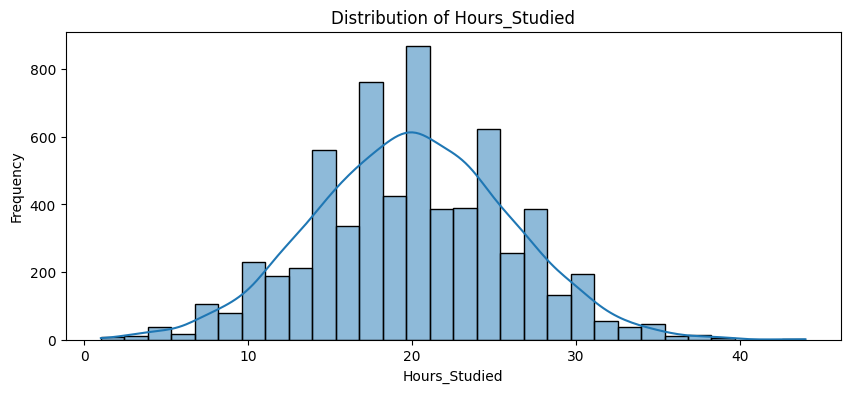

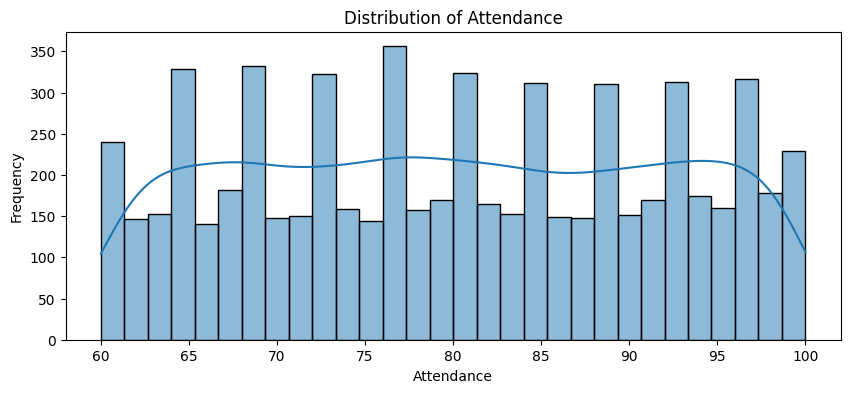

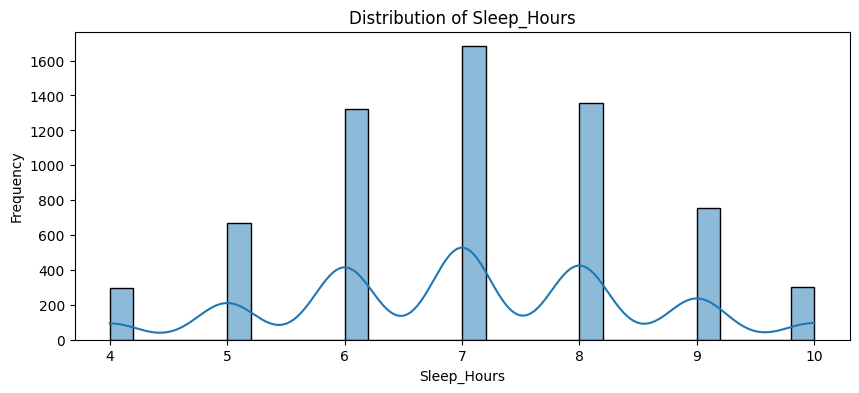

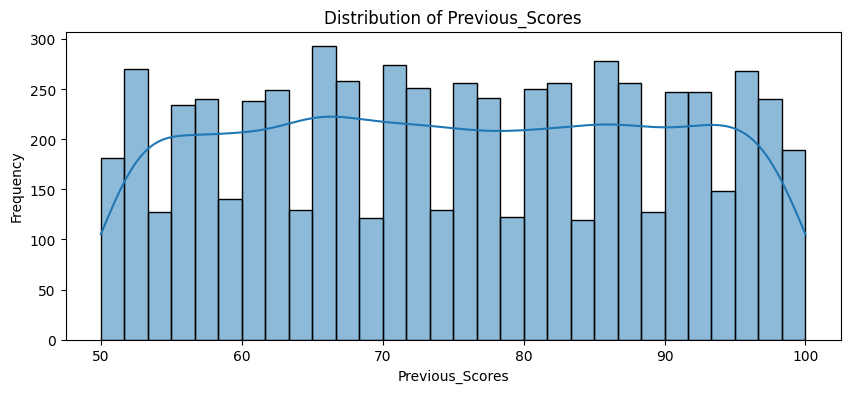

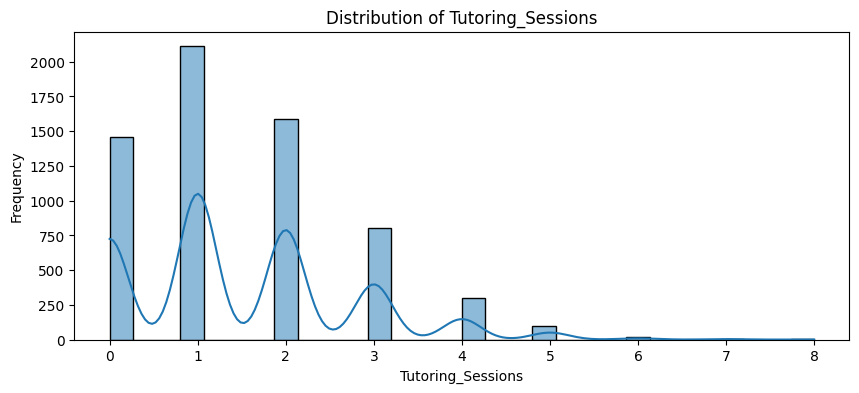

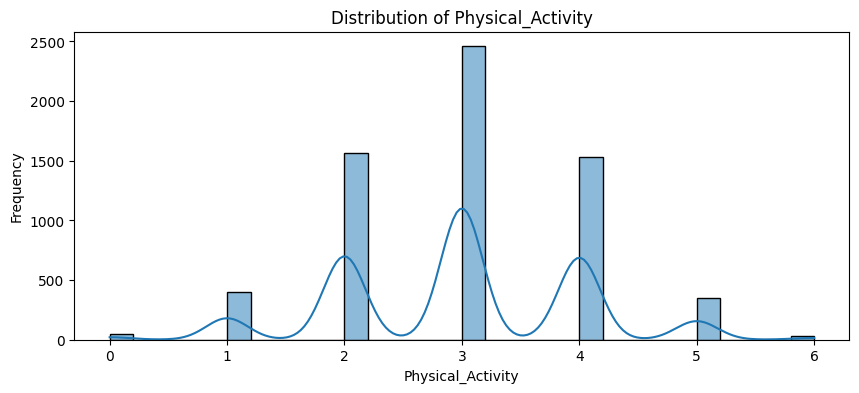

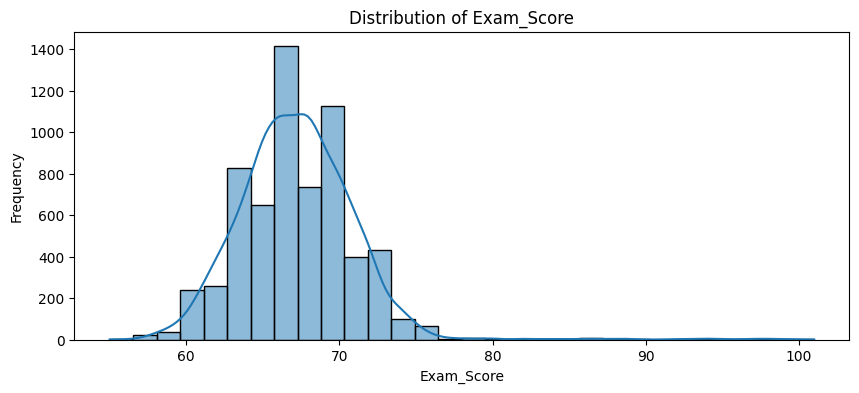

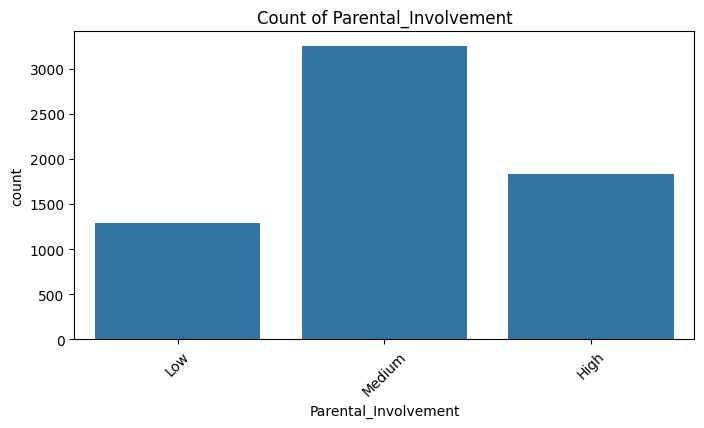

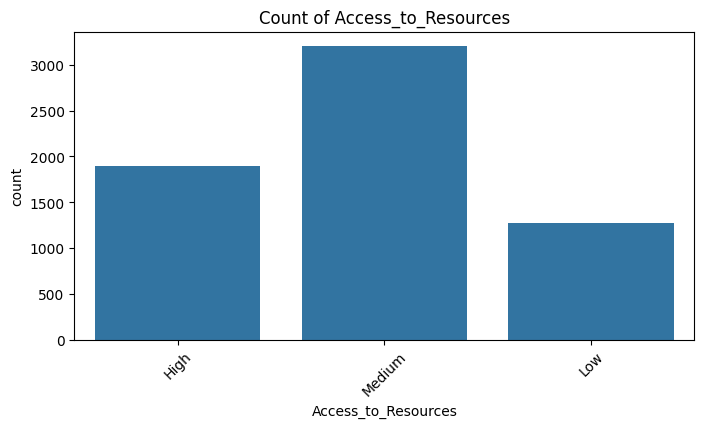

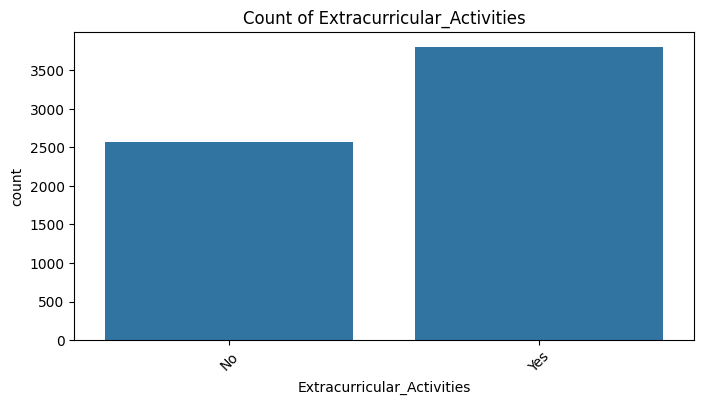

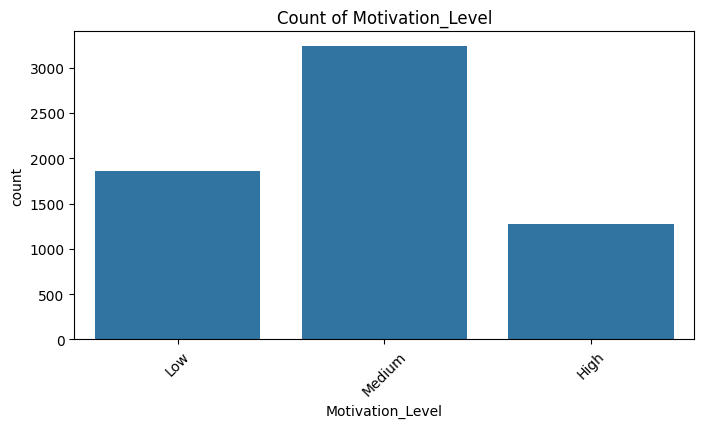

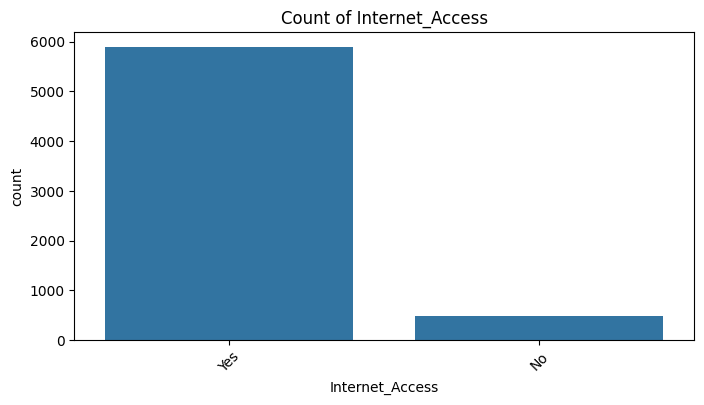

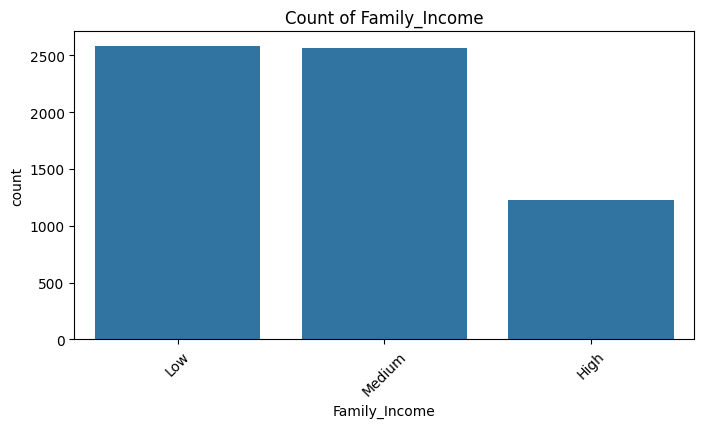

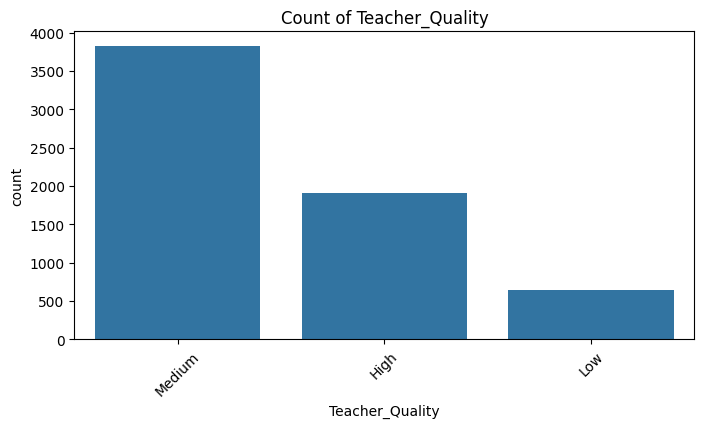

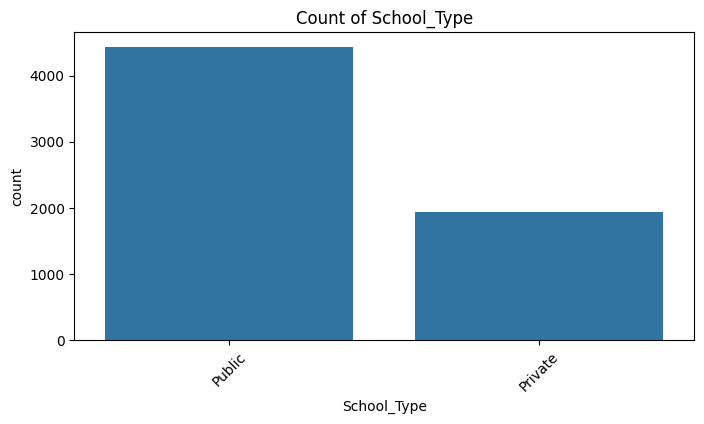

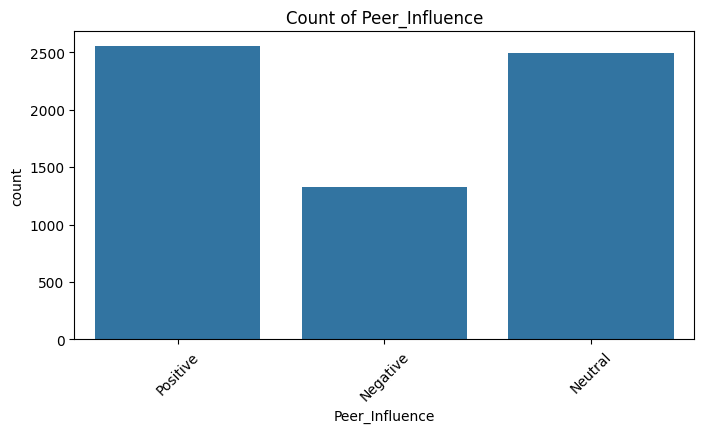

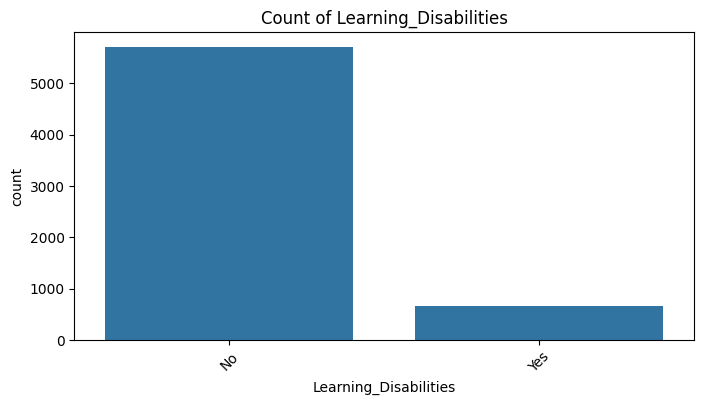

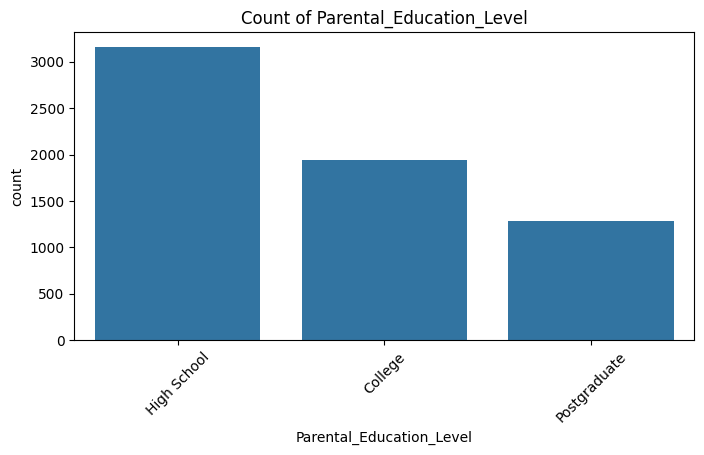

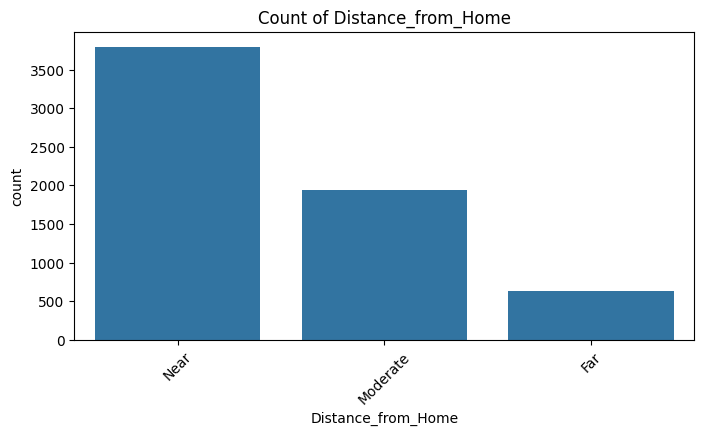

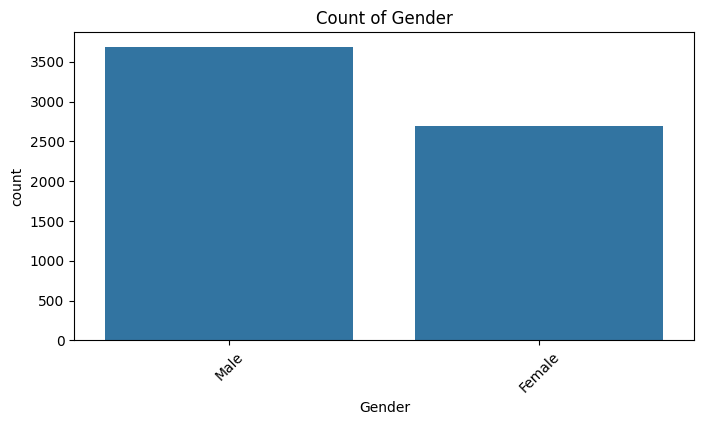

In [16]:

# Visualize numerical features
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Visualize categorical features
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

# Convert categorical features to numerical using LabelEncoder

In [19]:
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


##  Remove outliers using IQR

In [20]:
Q1 = data[numerical_cols].quantile(0.25)
Q3 = data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_condition = ((data[numerical_cols] < (Q1 - 1.5 * IQR)) | (data[numerical_cols] > (Q3 + 1.5 * IQR)))
outliers_iqr = outlier_condition.any(axis=1)
print(f'Number of outlier rows using IQR: {np.sum(outliers_iqr)}')

data_cleaned = data[~outliers_iqr]
print(f'Cleaned data shape: {data_cleaned.shape}')

Number of outlier rows using IQR: 542
Cleaned data shape: (5836, 20)


## Split data into features and target

In [21]:
X = data.drop(columns=['Exam_Score'])
y = data['Exam_Score']

Xo = data_cleaned.drop(columns=['Exam_Score'])
yo = data_cleaned['Exam_Score']



##  Split into training and testing sets

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(Xo, yo, test_size=0.3, random_state=42)


## Train linear regression models

In [23]:
model1 = LinearRegression()
model2 = LinearRegression()


In [24]:

model1.fit(X_train, y_train)
model2.fit(X_train_o, y_train_o)


LinearRegression()

In [25]:
# Predictions
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test_o)

In [27]:
# Performance metrics
mse1 = mean_squared_error(y_test, y_pred1)
mse2 = mean_squared_error(y_test_o, y_pred2)
r2_1 = r2_score(y_test, y_pred1)
r2_2 = r2_score(y_test_o, y_pred2)
print(f'Mean squared error with outliers: {mse1}')
print(f'R^2 score with outliers: {r2_1}')
print(f'Mean squared error without outliers: {mse2}')
print(f'R^2 score without outliers: {r2_2}')


Mean squared error with outliers: 5.082607986941271
R^2 score with outliers: 0.667793876099538
Mean squared error without outliers: 1.2553294559648378
R^2 score without outliers: 0.8750173041982846


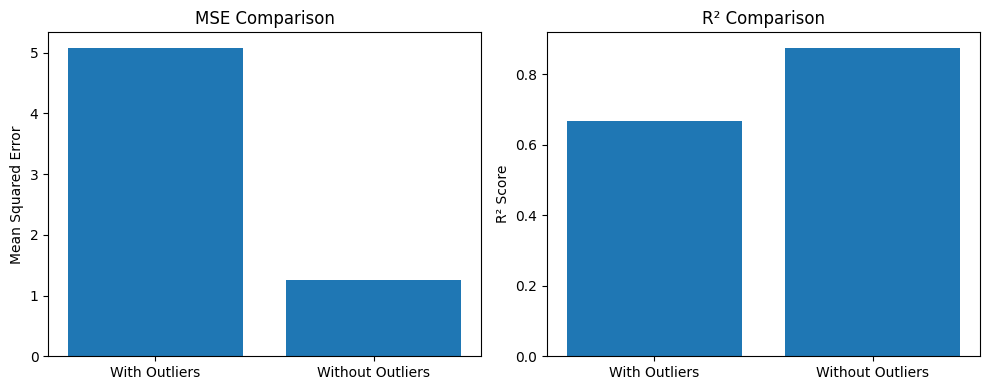

In [28]:
# Create comparison dataframe
performance = pd.DataFrame({
    'Model': ['With Outliers', 'Without Outliers'],
    'MSE': [mse1, mse2],
    'R2': [r2_1, r2_2]
})

# Plot MSE comparison
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(performance['Model'], performance['MSE'])
plt.title('MSE Comparison')
plt.ylabel('Mean Squared Error')

# Plot R2 comparison
plt.subplot(1,2,2)
plt.bar(performance['Model'], performance['R2'])
plt.title('R² Comparison')
plt.ylabel('R² Score')

plt.tight_layout()
plt.show()

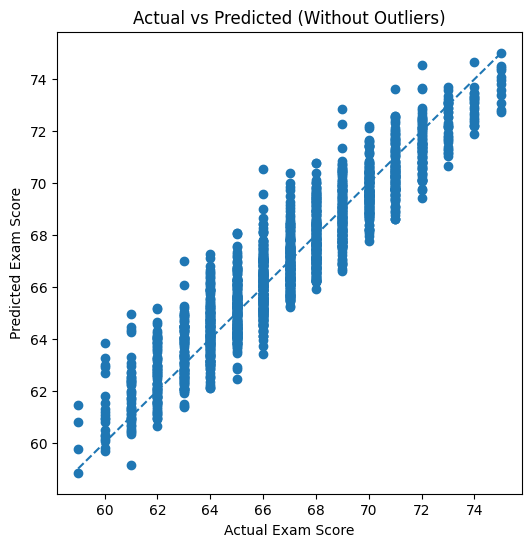

In [29]:
# For model without outliers

plt.figure(figsize=(6,6))
plt.scatter(y_test_o, y_pred2)
plt.plot([y_test_o.min(), y_test_o.max()],
         [y_test_o.min(), y_test_o.max()],
         linestyle='--')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted (Without Outliers)')
plt.show()

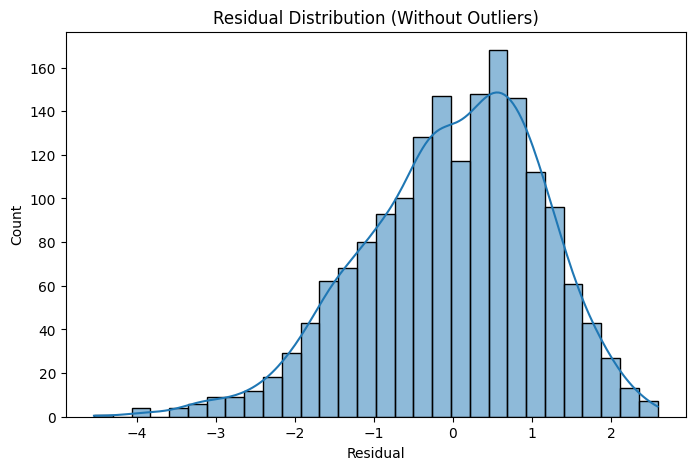

In [30]:
residuals = y_test_o - y_pred2

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residual Distribution (Without Outliers)')
plt.xlabel('Residual')
plt.show()